In [1]:
from fastai.vision.all import *

In [ ]:
# Load models
base_model = load_learner('fine_tuned_plant_classifier_model_v1_base.pkl')
final_model = load_learner('v2pruned_plant_classifier.pkl')
pruned = load_learner('pruned_plant_classifier.pkl')
pruned7 = load_learner('pruned7_plant_classifier.pkl')
frozen = load_learner('frozenfine_plant_classifier.pkl')
frozen7 = load_learner('frozenfine7_plant_classifier.pkl')

In [3]:
# Load the DataLoaders
with open('v1_dls.pkl', 'rb') as f:
    base_model.dls = pickle.load(f)

with open('v2pruned_dls.pkl', 'rb') as f:
    final_model.dls = pickle.load(f)

with open('pruned_dls.pkl', 'rb') as f:
    pruned.dls = pickle.load(f)

with open('pruned7_dls.pkl', 'rb') as f:
    pruned7.dls = pickle.load(f)

with open('frozenfine_dls.pkl', 'rb') as f:
    frozen.dls = pickle.load(f)

with open('frozenfine7_dls.pkl', 'rb') as f:
    frozen7.dls = pickle.load(f)

In [ ]:
#Enter evaluation mode
bmodel = base_model.model.eval()
fmodel = final_model.model.eval()
pmodel = pruned.model.eval()
p7model = pruned7.model.eval()
ffmodel = frozen.model.eval()
ff7model = frozen7.model.eval()

In [5]:
total_params_before = sum(p.numel() for p in bmodel.parameters())
print(f"Total parameters base: {total_params_before}")

total_params_before = sum(p.numel() for p in fmodel.parameters())
print(f"Total parameters final: {total_params_before}")

total_params_before = sum(p.numel() for p in pmodel.parameters())
print(f"Total parameters pruned: {total_params_before}")

total_params_before = sum(p.numel() for p in p7model.parameters())
print(f"Total parameters pruned7: {total_params_before}")

total_params_before = sum(p.numel() for p in ffmodel.parameters())
print(f"Total parameters frozen: {total_params_before}")

total_params_before = sum(p.numel() for p in ff7model.parameters())
print(f"Total parameters frozen7: {total_params_before}")

Total parameters base: 11721280
Total parameters final: 9857776
Total parameters pruned: 11721280
Total parameters pruned7: 11721280
Total parameters frozen: 11721280
Total parameters frozen7: 11721280


In [7]:
base_model.validate()

(#2) [0.40694406628608704,0.9024814963340759]

In [8]:
final_model.validate()

(#2) [0.4182215929031372,0.8785372376441956]

In [10]:
pruned.validate()

(#2) [3.607093572616577,0.13365259766578674]

In [11]:
pruned7.validate()

(#2) [5.123471736907959,0.021767523139715195]

In [12]:
frozen.validate()

(#2) [0.5289552807807922,0.8685241341590881]

In [13]:
frozen7.validate()

(#2) [1.3096569776535034,0.6926425695419312]

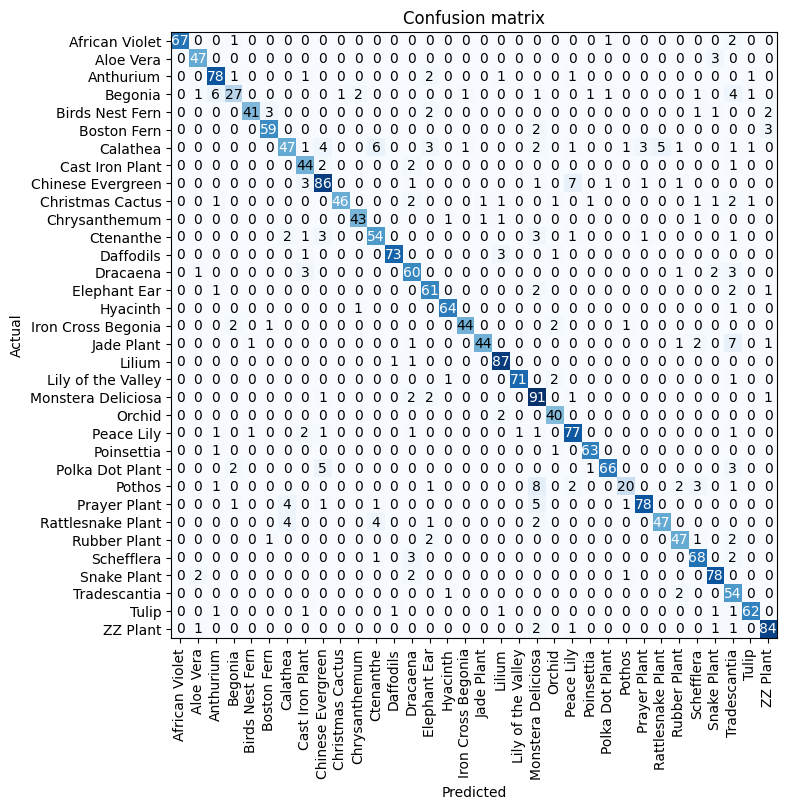

In [14]:
# Confusion Matrix
from fastai.interpret import ClassificationInterpretation

interp = ClassificationInterpretation.from_learner(final_model)
interp.plot_confusion_matrix(figsize=(8,8))